In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
path = r"..\Data\cleaned_customer.csv"
df = pd.read_csv(path)

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1


In [12]:
customers_per_country = (
    df.groupby('Country')['CustomerID']
    .nunique()
    .reset_index(name='Customer_Count')
    .sort_values(by='Customer_Count', ascending=False)
)

customers_per_country

,Country,Customer_Count
35,United Kingdom,3950
14,Germany,95
13,France,87
30,Spain,31
3,Belgium,25
32,Switzerland,21
26,Portugal,19
18,Italy,15
12,Finland,12
1,Austria,11


In [13]:
total_customers = customers_per_country['Customer_Count'].sum()

customers_per_country['Percentage'] = (
    customers_per_country['Customer_Count'] / total_customers * 100
)

top_countries = customers_per_country.head(10)

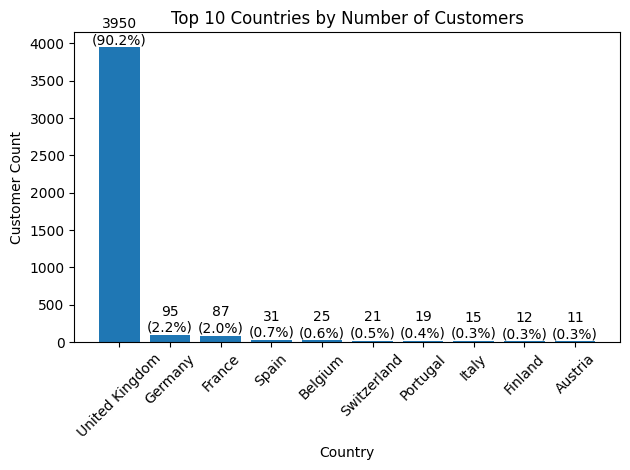

In [14]:
plt.figure()

bars = plt.bar(top_countries['Country'], top_countries['Customer_Count'])

# Add labels on top of bars
for bar, count, pct in zip(bars, top_countries['Customer_Count'], top_countries['Percentage']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{count}\n({pct:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.title('Top 10 Countries by Number of Customers')
plt.xlabel('Country')
plt.ylabel('Customer Count')

plt.tight_layout()
plt.show()

In [15]:
customer_visits = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index(name='Visit_Count')
)

customer_country = (
    df.groupby('CustomerID')['Country']
    .first()
    .reset_index()
)
customer_data = customer_visits.merge(customer_country, on='CustomerID')

In [17]:
top_customers = (
    customer_data.sort_values(by='Visit_Count', ascending=False)
    .head(10)
)

top_customers

,CustomerID,Visit_Count,Country
1895,14911.0,248,EIRE
330,12748.0,224,United Kingdom
4042,17841.0,169,United Kingdom
1674,14606.0,128,United Kingdom
2192,15311.0,118,United Kingdom
568,13089.0,118,United Kingdom
487,12971.0,89,United Kingdom
1615,14527.0,86,United Kingdom
803,13408.0,81,United Kingdom
1703,14646.0,77,Netherlands


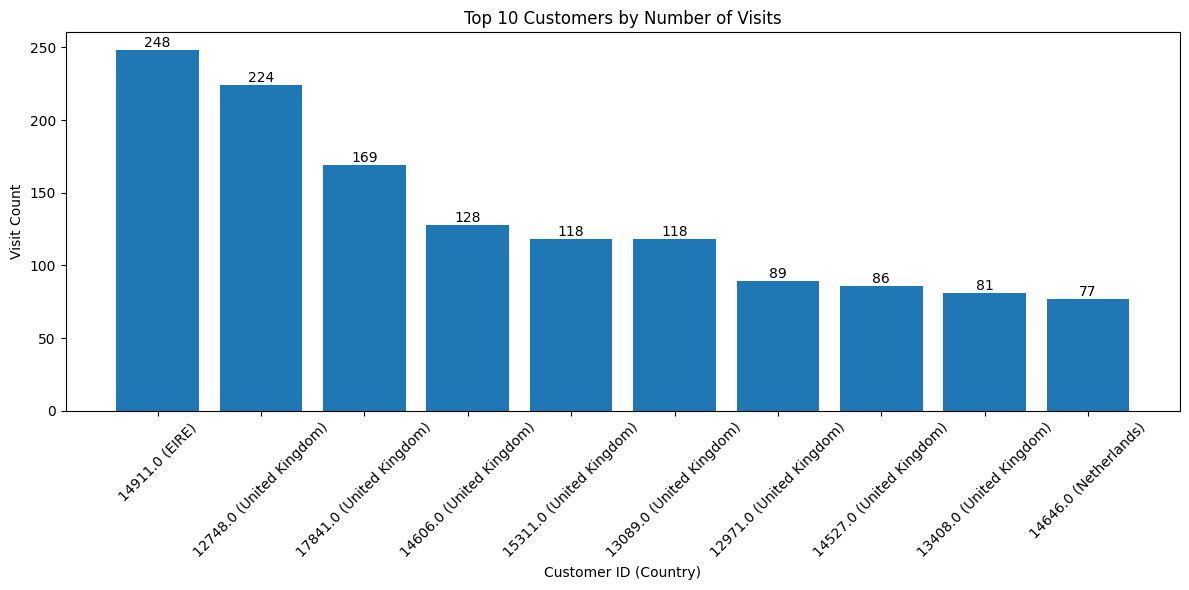

In [18]:
plt.figure(figsize=(12,6))

# Create combined labels
labels = top_customers['CustomerID'].astype(str) + ' (' + top_customers['Country'] + ')'

bars = plt.bar(labels, top_customers['Visit_Count'])

# Add labels on top
for bar, count in zip(bars, top_customers['Visit_Count']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(count),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.title('Top 10 Customers by Number of Visits')
plt.xlabel('Customer ID (Country)')
plt.ylabel('Visit Count')

plt.tight_layout()
plt.show()

In [19]:
customer_spend = (
    df.groupby('CustomerID')['TotalPrice']
    .sum()
    .reset_index(name='Total_Spending')
)

customer_country = (
    df.groupby('CustomerID')['Country']
    .first()
    .reset_index()
)

customer_data = customer_spend.merge(customer_country, on='CustomerID')

top_spenders = (
    customer_data.sort_values(by='Total_Spending', ascending=False)
    .head(10)
)

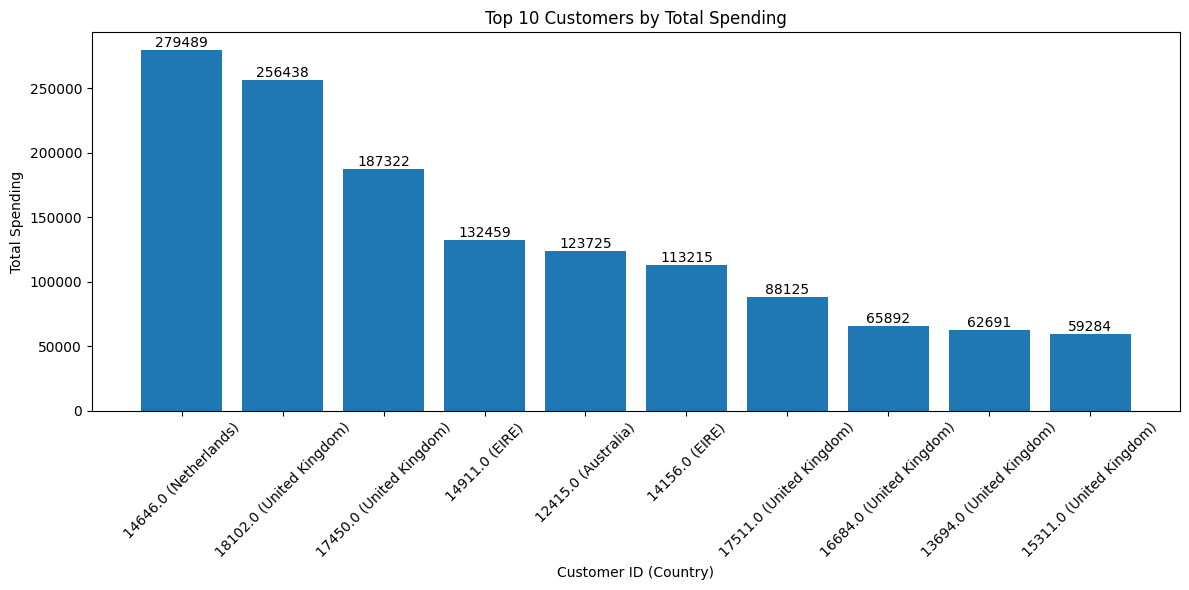

In [20]:
plt.figure(figsize=(12,6))

labels = top_spenders['CustomerID'].astype(str) + ' (' + top_spenders['Country'] + ')'

bars = plt.bar(labels, top_spenders['Total_Spending'])

# Add labels
for bar, value in zip(bars, top_spenders['Total_Spending']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:.0f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID (Country)')
plt.ylabel('Total Spending')

plt.tight_layout()
plt.show()

In [21]:
unknown_customers = df[
    (df['CustomerID'] == 0)
]

country_counts = (
    unknown_customers.groupby('Country')['InvoiceNo']
    .nunique()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
)

top_countries = country_counts.head(10)

total = top_countries['Count'].sum()
top_countries['Percentage'] = (top_countries['Count'] / total) * 100

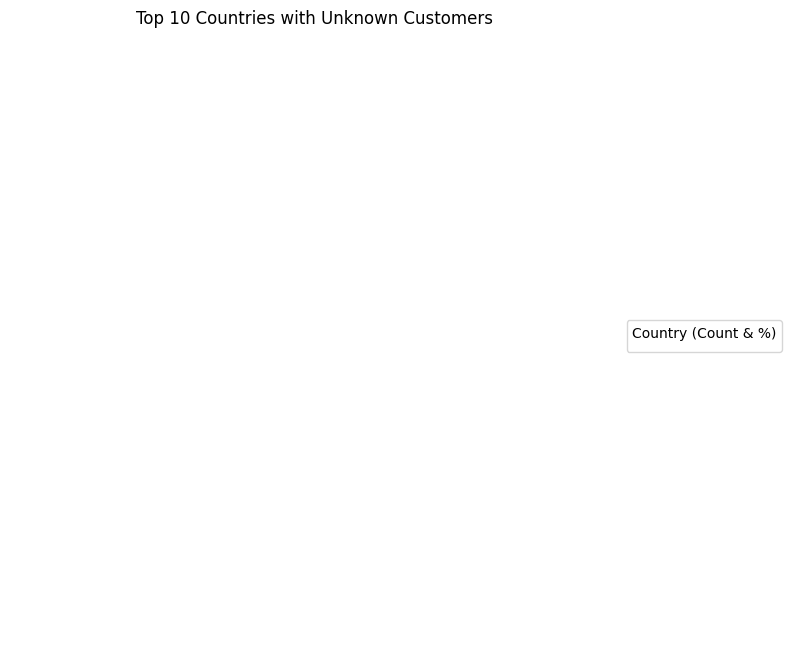

In [22]:
plt.figure(figsize=(8,8))

counts = top_countries['Count']
labels = top_countries['Country']

# Create legend labels with count + percentage
total = counts.sum()
legend_labels = [
    f"{country} - {count} ({(count/total)*100:.1f}%)"
    for country, count in zip(labels, counts)
]

# Plot pie (NO numbers inside)
wedges, texts = plt.pie(
    counts,
    startangle=140
)

# Add legend
plt.legend(
    wedges,
    legend_labels,
    title="Country (Count & %)",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title('Top 10 Countries with Unknown Customers')

plt.tight_layout()
plt.show()

In [23]:
top_products = (
    df.groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .reset_index(name='Total_Quantity')
    .sort_values(by='Total_Quantity', ascending=False)
)

top_10_products = top_products.head(10)

top_10_products

,StockCode,Description,Total_Quantity
3028,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53119
3460,85099B,JUMBO BAG RED RETROSPOT,44963
3288,84879,ASSORTED COLOUR BIRD ORNAMENT,35215
3475,85123A,WHITE HANGING HEART T-LIGHT HOLDER,34128
434,21212,PACK OF 72 RETROSPOT CAKE CASES,33386
1112,22197,POPCORN HOLDER,30492
2010,23084,RABBIT NIGHT LIGHT,27045
1387,22492,MINI PAINT SET VINTAGE,25880
1509,22616,PACK OF 12 LONDON TISSUES,25305
930,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24129


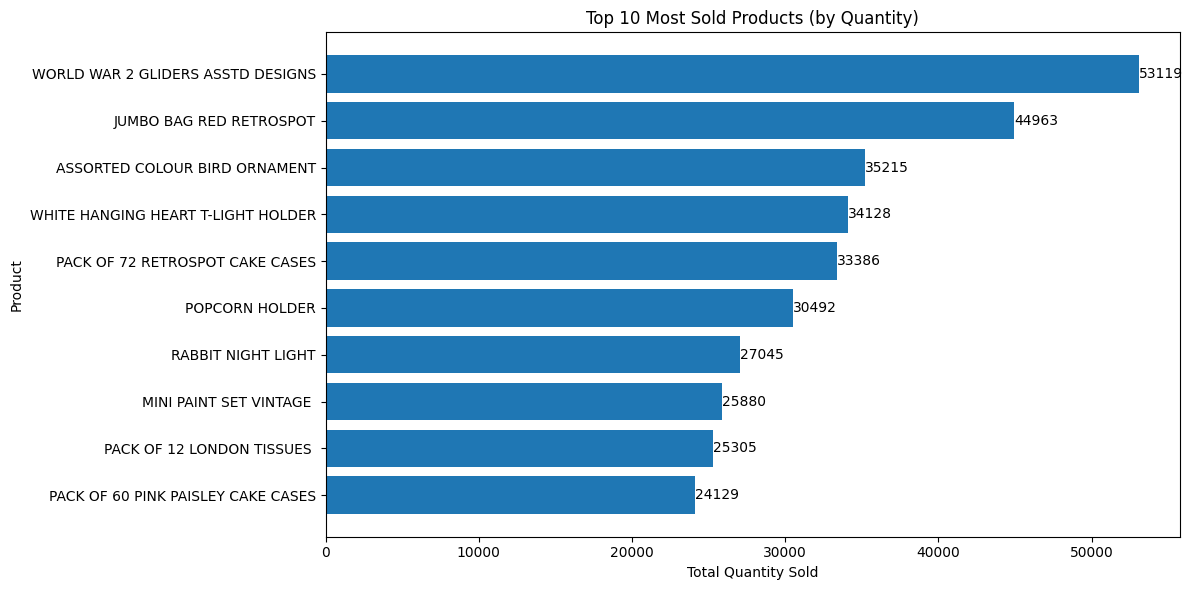

In [24]:
plt.figure(figsize=(12,6))

labels = top_10_products['Description']

bars = plt.barh(labels, top_10_products['Total_Quantity'])

# Add values
for bar, value in zip(bars, top_10_products['Total_Quantity']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        str(int(value)),
        va='center'
    )

plt.title('Top 10 Most Sold Products (by Quantity)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

In [25]:
revenue_per_country = (
    df[df['Quantity'] > 0]
    .groupby('Country')['TotalPrice']
    .sum()
    .reset_index(name='Total_Revenue')
    .sort_values(by='Total_Revenue', ascending=False)
)

quantity_per_country = (
    df[df['Quantity'] > 0]
    .groupby('Country')['Quantity']
    .sum()
    .reset_index(name='Total_Quantity')
    .sort_values(by='Total_Quantity', ascending=False)
)

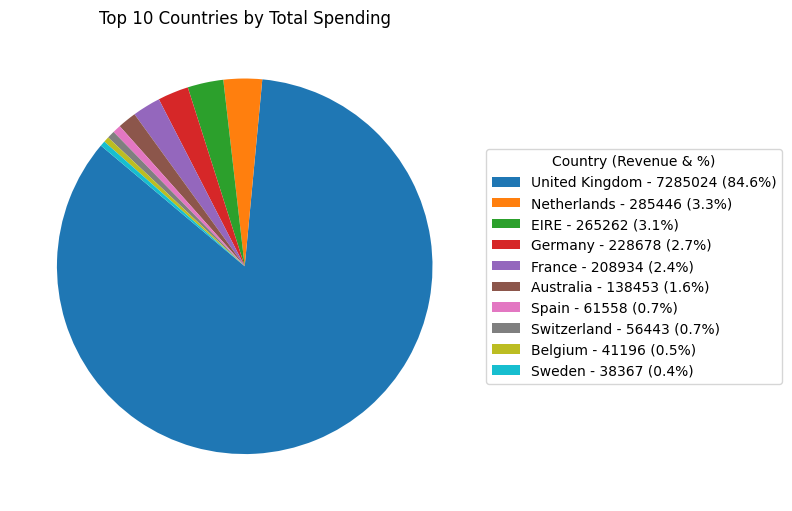

In [26]:
top_countries = revenue_per_country.head(10)

counts = top_countries['Total_Revenue']
labels = top_countries['Country']

total = counts.sum()

legend_labels = [
    f"{country} - {int(value)} ({(value/total)*100:.1f}%)"
    for country, value in zip(labels, counts)
]

plt.figure(figsize=(8,8))

wedges, _ = plt.pie(counts, startangle=140)

plt.legend(
    wedges,
    legend_labels,
    title="Country (Revenue & %)",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title('Top 10 Countries by Total Spending')

plt.tight_layout()
plt.show()

In [27]:
product_price = (
    df.groupby(['StockCode', 'Description'])['UnitPrice']
    .mean()   # or .max() if you want highest listed price
    .reset_index()
)

In [28]:
top_expensive = (
    product_price.sort_values(by='UnitPrice', ascending=False)
    .head(10)
)

top_expensive

,StockCode,Description,UnitPrice
3912,DOT,DOTCOM POSTAGE,744.147500
1397,22502,PICNIC BASKET WICKER 60 PIECES,649.500000
3910,CRUK,CRUK Commission,495.839375
3913,M,Manual,338.044391
1723,22828,REGENCY MIRROR WITH SHUTTERS,156.428571
1722,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,156.034483
1548,22655,VINTAGE RED KITCHEN CABINET,150.663043
1549,22656,VINTAGE BLUE KITCHEN CABINET,143.653846
1718,22823,CHEST NATURAL WOOD 20 DRAWERS,118.076923
1721,22826,LOVE SEAT ANTIQUE WHITE METAL,115.388889


In [29]:
top_cheapest = (
    product_price[product_price['UnitPrice'] > 0]  # remove free/zero items
    .sort_values(by='UnitPrice', ascending=True)
    .head(10)
)

top_cheapest

,StockCode,Description,UnitPrice
3914,PADS,PADS TO MATCH ALL CUSHIONS,0.000750
35,16045,POPART WOODEN PENCILS ASST,0.043478
64,16218,CARTOON PENCIL SHARPENERS,0.073200
65,16219,HOUSE SHAPE PENCIL SHARPENER,0.090208
63,16216,LETTER SHAPE PENCIL SHARPENER,0.094634
90,17038,PORCELAIN BUDAH INCENSE HOLDER,0.095263
75,16259,PIECE OF CAMO STATIONERY SET,0.096250
45,16161G,WRAP BAD HAIR DAY,0.100000
106,17136A,BLUE STONES ON WIRE FOR CANDLE,0.102941
137,20668,DISCO BALL CHRISTMAS DECORATION,0.118478


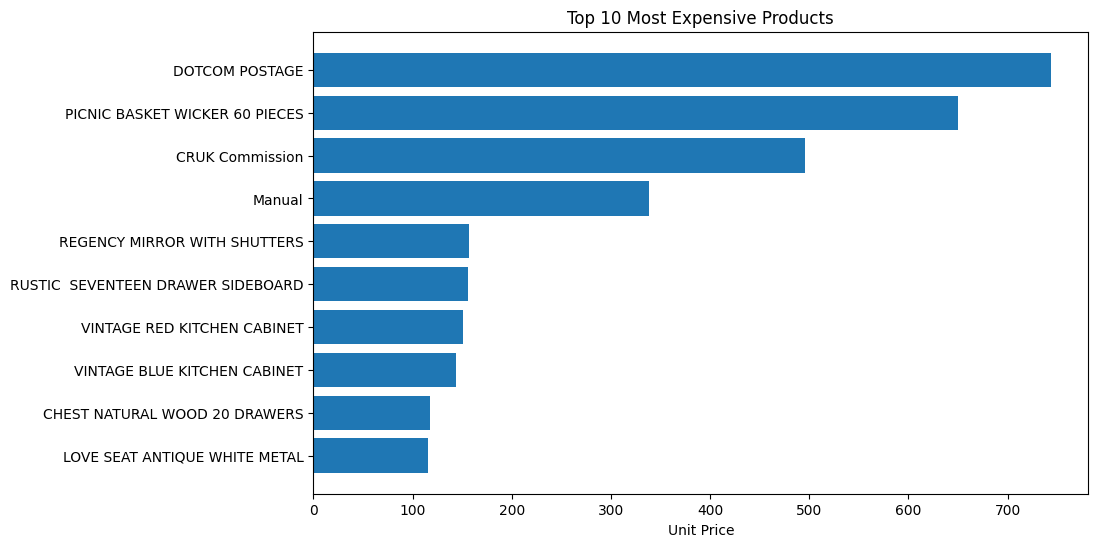

In [30]:
plt.figure(figsize=(10,6))
plt.barh(top_expensive['Description'], top_expensive['UnitPrice'])

plt.title('Top 10 Most Expensive Products')
plt.xlabel('Unit Price')
plt.gca().invert_yaxis()
plt.show()

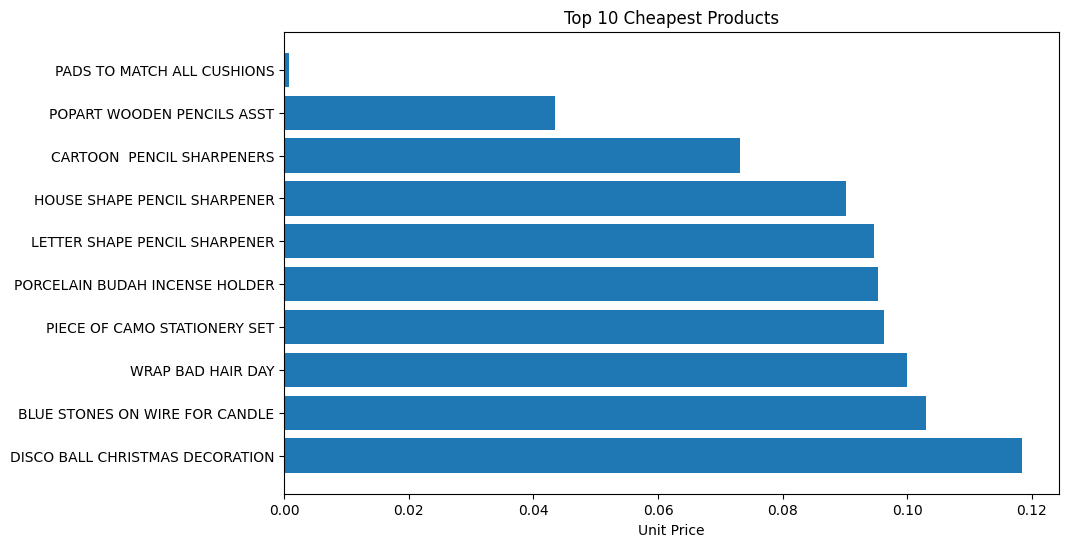

In [31]:
plt.figure(figsize=(10,6))
plt.barh(top_cheapest['Description'], top_cheapest['UnitPrice'])

plt.title('Top 10 Cheapest Products')
plt.xlabel('Unit Price')
plt.gca().invert_yaxis()
plt.show()

In [32]:
invoice_value = (
    df[df['Quantity'] > 0]
    .groupby('InvoiceNo')['TotalPrice']
    .sum()
    .reset_index(name='Invoice_Total')
)

invoice_country = (
    df.groupby('InvoiceNo')['Country']
    .first()
    .reset_index()
)

invoice_data = invoice_value.merge(invoice_country, on='InvoiceNo')

top_invoices = (
    invoice_data.sort_values(by='Invoice_Total', ascending=False)
    .head(10)
)

top_invoices

,InvoiceNo,Invoice_Total,Country
18503,581483,168469.60,United Kingdom
1909,541431,77183.60,United Kingdom
7926,556444,38970.00,United Kingdom
12419,567423,31698.16,United Kingdom
8112,556917,22775.93,Australia
14459,572209,22206.00,United Kingdom
12411,567381,22104.80,United Kingdom
10843,563614,21880.44,Australia
5463,550461,21535.90,United Kingdom
14371,572035,20277.92,Netherlands


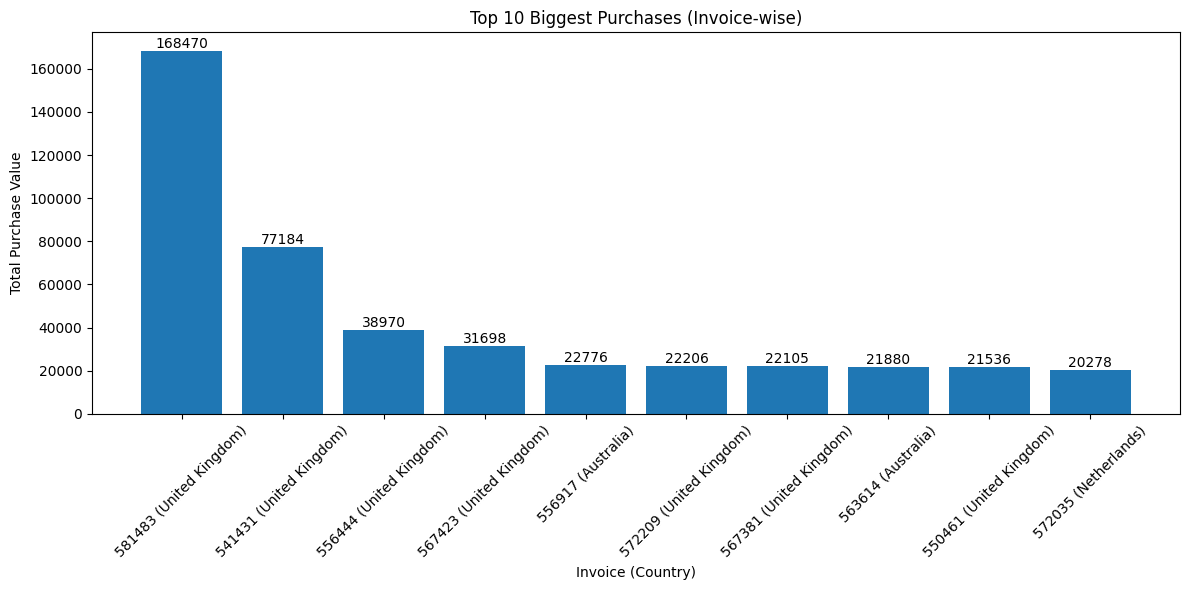

In [33]:
plt.figure(figsize=(12,6))

labels = top_invoices['InvoiceNo'].astype(str) + ' (' + top_invoices['Country'] + ')'

bars = plt.bar(labels, top_invoices['Invoice_Total'])

# Add values
for bar, value in zip(bars, top_invoices['Invoice_Total']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:.0f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.title('Top 10 Biggest Purchases (Invoice-wise)')
plt.xlabel('Invoice (Country)')
plt.ylabel('Total Purchase Value')

plt.tight_layout()
plt.show()

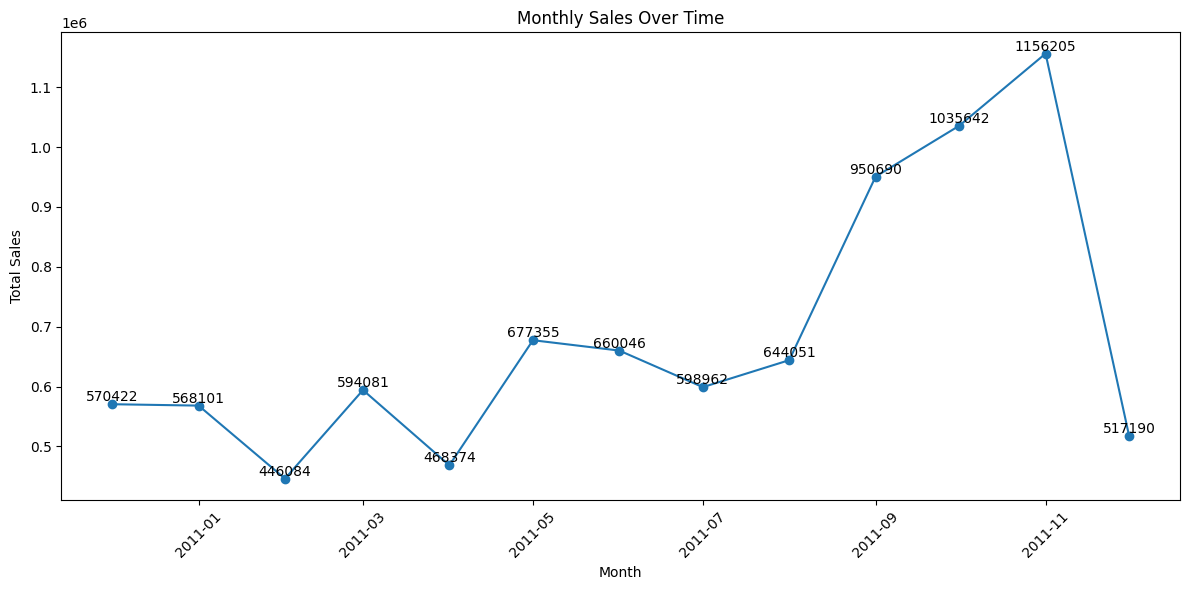

In [34]:
monthly_sales = (
    df[df['Quantity'] > 0]
    .groupby(['Year', 'Month'])['TotalPrice']
    .sum()
    .reset_index(name='Total_Sales')
)
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Date'], monthly_sales['Total_Sales'], marker='o')

# Add values on points
for x, y in zip(monthly_sales['Date'], monthly_sales['Total_Sales']):
    plt.text(x, y, f'{int(y)}', ha='center', va='bottom')

plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()